In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Hancom Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

In [2]:
df = pd.read_csv("Steel_industry_data.csv")

In [3]:
df.columns = ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
               'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
               'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
               'WeekStatus', 'Day_of_week', 'Load_Type']

print()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_ppm                               35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6),

<big><b> Attribute Information: </b></big>

<pre>
<b>Date</b>              Continuous-time data taken on the first of the month  
<b>Usage_kWh</b>         Industry Energy Consumption Continuous kWh  
<b>Lagging Current</b>   reactive power Continuous kVarh  
<b>Leading Current</b>   reactive power Continuous kVarh  
<b>CO2_ppm</b>           Continuous ppm  
<b>NSM</b>               Number of Seconds from midnight Continuous S  
<b>Week status</b>       Categorical (Weekend (0) or a Weekday(1))
<b>Day of week</b>       Categorical Sunday, Monday : Saturday  
<b>Load Type</b>         Categorical Light Load, Medium Load, Maximum Load
</pre>

# <b> [Phase 1: 데이터 기초 체력 다지기]

[Phase 1-2] 파이썬 실행 코드 (Feature Engineering)

In [4]:
import pandas as pd
import numpy as np

# 1. 시간 기준 오름차순 정렬 (가장 중요한 선행 작업)
# 'timestamp' 부분은 실제 사용 중인 날짜/시간 컬럼명으로 변경해야 합니다.
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(by='date', ascending=True)

# 2. 기존의 꼬인 인덱스를 완전히 파기하고 순차적인 새 인덱스 부여
df = df.reset_index(drop=True)

In [5]:


# 1. 시간 기반 피처 (NSM 활용)
# 시간 관련 피처 추출 (한국 전력 요금 체계 대응용)
df['Hour'] = df['NSM'] // 3600
df['DayOfWeek'] = df['date'].dt.dayofweek # 0:월, 6:일
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

### [수정] 한전 기준 계절로 매핑
# df['Season'] = df['Month'].map(
#                                     lambda x: 'Spring' if x in [3,4,5]
#                                     else 'Summer' if x in [6,7,8]
#                                     else 'Autumn' if x in [9,10,11]
#                                     else 'Winter'
#                                 )
df['Season'] = df['Month'].map(
                                    lambda x: 'Spring_Fall' if x in [3,4,5, 9, 10]
                                    else 'Summer' if x in [6,7,8]
                                    else 'Winter'
                                )



In [6]:
###[수정] 주, 월에 순환성 부여하는 코드
# 모델링 후에 활용여부 확인필요

cyclic_targets = {'Month': 12, 'DayOfWeek': 7}

for col, period in cyclic_targets.items():
    # 이제 target_df[col]은 확실히 숫자이므로 계산이 가능합니다.
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col].astype(float) / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col].astype(float) / period)

print("성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.")

성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.


In [7]:

# 2. 전력 품질 피처 (역률 및 비율)
# 무효전력 합계 (전체 흐르는 전기 에너지의 규모)
### [수정] 컬럼명 추후 활용도 높게 수정
# df['Total_Reactive_Power'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 인프라가 감당하는 물리적 부하량 (지상+진상 절대 합계)
df['System_Stress_Load'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 유효전력 대비 무효전력 비율 (비효율 지표)
# 0으로 나누기 방지를 위해 작은 값(1e-6) 추가
### [수정] 시각화 진행 시 노이즈 방지를 위해 1e-6 추가 처리.
# Usage_kWh가 0이면 0을 부여, 0이 아니면 계산 수행
# 2. 유효전력 대비 무효전력 집약도 (운영 효율 지표)
# Usage가 0인 구간(비가동)은 0으로 처리하여 시각화 스파이크 방지
df['Reactive_Intensity'] = np.where( df['Usage_kWh'] > 0,  df['System_Stress_Load'] / df['Usage_kWh'], 0)


# # 피타고라스 정리를 이용한 종합 역률 계산
# df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
# df['Power_Factor'] = df['Usage_kWh'] / (df['Apparent_Power'] + 1e-6)
### [수정] 역률지표의 구분, 1-6승에 대한 부분 처리
# 순무효전력 기반 물리적 역률
df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
df['PF_Physical'] = np.where(df['Apparent_Power'] > 0, df['Usage_kWh'] / df['Apparent_Power'], 1.0)


# 3. 변동성 및 추세 피처
# 시계열 데이터이므로 순서대로 정렬되어 있다고 가정
### [수정] 모델을 시계열로 돌리지 않는 상황이므로 전력 사용량에 대한 피쳐는 삭제(다중공선성 우려)
# df['Usage_Moving_Avg_1h_mean'] = df['Usage_kWh'].rolling(window=4).mean() # 1시간(15분*4) 이동평균
# 전력 사용의 흔들림에 대한 내용이므로 유지
df['Motor_Moving_Avg_1h_std'] = df['Usage_kWh'].rolling(window=4, min_periods=2).std().bfill() # 1시간(15분*4) 이동평균 표준편차


print("파생 피처 생성 완료. 상위 5개 행 확인:")
print(df.head())

파생 피처 생성 완료. 상위 5개 행 확인:
                 date  Usage_kWh  Lagging_Current_Reactive_Power_kVarh  \
0 2018-01-01 00:00:00       3.42                                  3.46   
1 2018-01-01 00:15:00       3.17                                  2.95   
2 2018-01-01 00:30:00       4.00                                  4.46   
3 2018-01-01 00:45:00       3.24                                  3.28   
4 2018-01-01 01:00:00       3.31                                  3.56   

   Leading_Current_Reactive_Power_kVarh  CO2_ppm  \
0                                   0.0      0.0   
1                                   0.0      0.0   
2                                   0.0      0.0   
3                                   0.0      0.0   
4                                   0.0      0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         70.30                         100.0     0   
1                         73.21                         100.0   900   
2   

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'Critical Flaw 1: Power Usage vs CO2 by Day of Week')

Text(0.5, 0, 'Usage_kWh (Physical Truth)')

Text(0, 0.5, 'CO2_ppm (Sensor Data)')

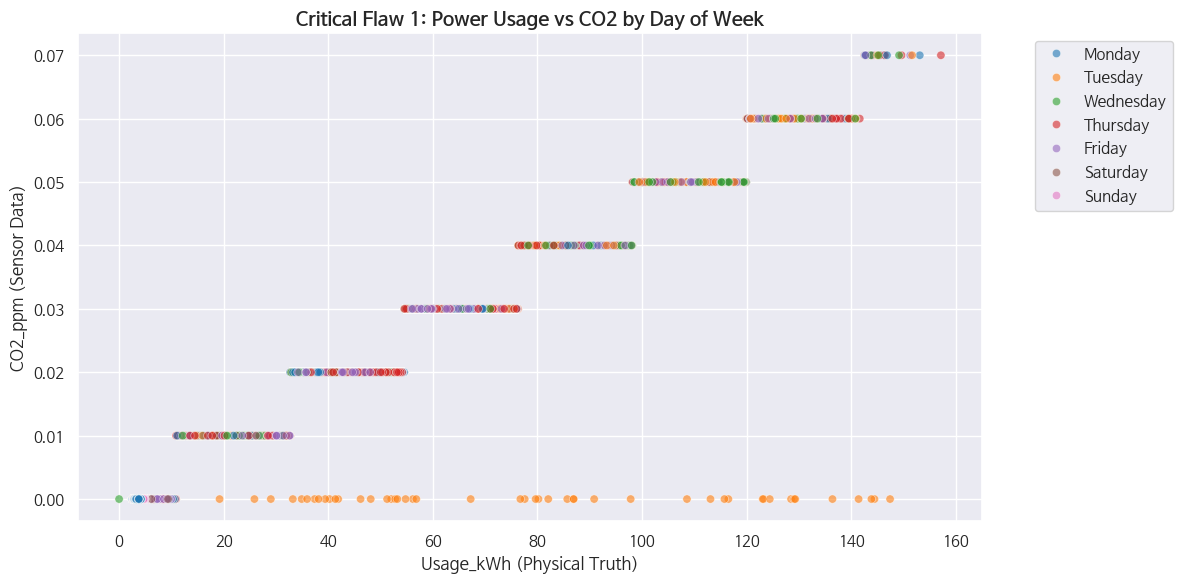

▶ 가동 중(전력 10kWh 이상) 요일별 CO2 결측 비율(%)
Day_of_week  Zero_CO2_Percentage
    Tuesday             2.212389
     Sunday             1.289134
   Saturday             0.298285
     Monday             0.287711
   Thursday             0.274402
  Wednesday             0.260191
     Friday             0.201532
--------------------------------------------------


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'Critical Flaw 2: Power Usage vs CO2 by Month (Focus on January)')

Text(0.5, 0, 'Usage_kWh (Physical Truth)')

Text(0, 0.5, 'CO2_ppm (Sensor Data)')

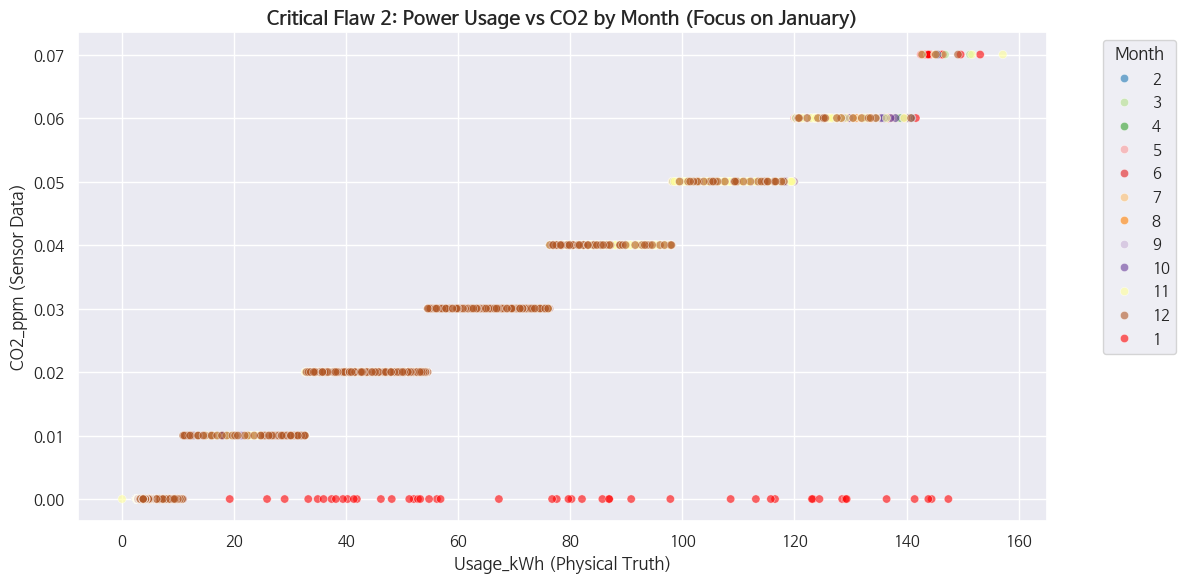

▶ 가동 중(전력 10kWh 이상) 월별 CO2 결측 비율(%)
 Month  Zero_CO2_Percentage
     1             3.196622
    12             0.564334
     9             0.526870
    10             0.397456
     6             0.381316
     4             0.337268
     2             0.327332
     3             0.240192
     8             0.199005
     5             0.176523
    11             0.159236
     7             0.155039
--------------------------------------------------


Text(0, 0.5, 'Usage_kWh (Blue)')

Text(0, 0.5, 'CO2_ppm (Red)')

Text(0.5, 1.0, 'Time-Series Proof: January Sensor Failure (Power Spikes, but CO2 Flatlines)')

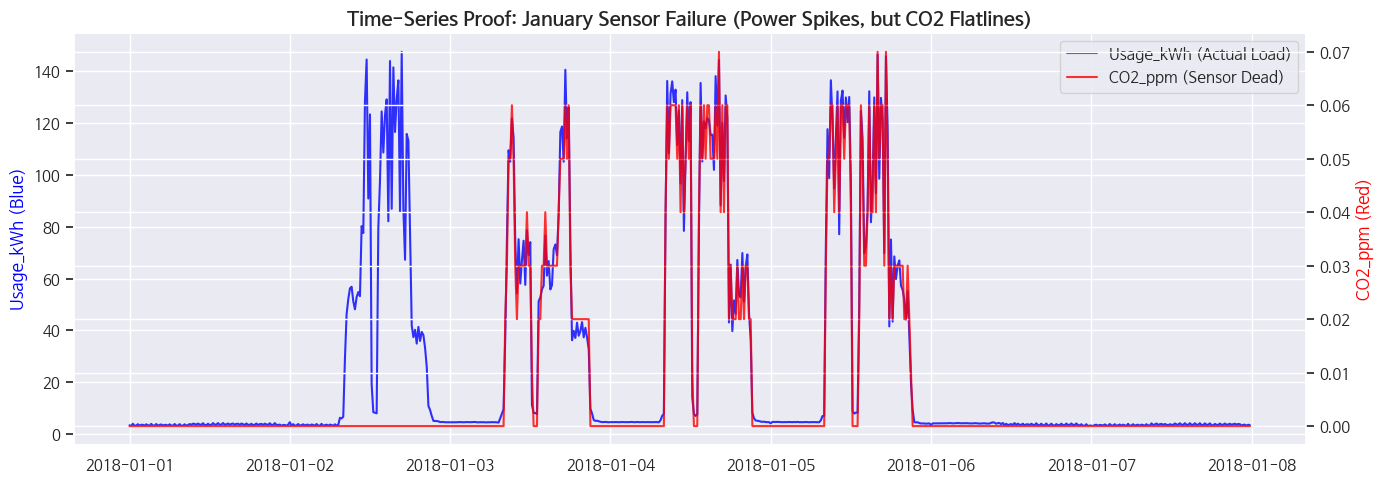

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. 요일별 물리적 모순 시각화 및 통계 (기존 코드 유지)
# =====================================================================
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Usage_kWh', y='CO2_ppm', hue='Day_of_week', palette='tab10', alpha=0.6)
plt.title('Critical Flaw 1: Power Usage vs CO2 by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Usage_kWh (Physical Truth)')
plt.ylabel('CO2_ppm (Sensor Data)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

active_df = df[df['Usage_kWh'] > 10.0]
zero_co2_day = active_df.groupby('Day_of_week').apply(
    lambda x: (x['CO2_ppm'] == 0).sum() / len(x) * 100
).reset_index(name='Zero_CO2_Percentage')

print("▶ 가동 중(전력 10kWh 이상) 요일별 CO2 결측 비율(%)")
print(zero_co2_day.sort_values(by='Zero_CO2_Percentage', ascending=False).to_string(index=False))
print("-" * 50)

# =====================================================================
# 2. 월별 물리적 모순 시각화 및 통계 (1월 집중 노이즈 증명)
# =====================================================================
# 12개의 색상을 지원하는 Paired 팔레트 로드
base_colors = sns.color_palette("Paired", 12)

# 1~12월에 색상 매핑
custom_palette = {m: base_colors[i] for i, m in enumerate(range(1, 13))}

# 1월의 색상만 튀는 색으로 강제 변경
custom_palette[1] = '#FF0000' # 강렬한 빨간색 지정

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='Usage_kWh', 
    y='CO2_ppm', 
    hue='Month', 
    palette=custom_palette, 
    alpha=0.6,
    hue_order=[m for m in range(2, 13)] + [1]
)

plt.title('Critical Flaw 2: Power Usage vs CO2 by Month (Focus on January)', fontsize=14, fontweight='bold')
plt.xlabel('Usage_kWh (Physical Truth)')
plt.ylabel('CO2_ppm (Sensor Data)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Month')
plt.tight_layout()
plt.show()
zero_co2_month = active_df.groupby('Month').apply(
    lambda x: (x['CO2_ppm'] == 0).sum() / len(x) * 100
).reset_index(name='Zero_CO2_Percentage')

print("▶ 가동 중(전력 10kWh 이상) 월별 CO2 결측 비율(%)")
print(zero_co2_month.sort_values(by='Zero_CO2_Percentage', ascending=False).to_string(index=False))
print("-" * 50)

# =====================================================================
# 3. 1월 시계열의 치명적 붕괴 증명 (Time-Series Proof)
# =====================================================================
# 1월 데이터 중 문제가 되었던 첫째 주(약 1주일 치, 672행)만 필터링
jan_sample = df[df['Month'] == 1].sort_values('date').head(672)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# 실제 공정 부하 (전력)
ax1.plot(jan_sample['date'], jan_sample['Usage_kWh'], color='blue', label='Usage_kWh (Actual Load)', alpha=0.8)
# 죽어버린 센서 데이터 (CO2)
ax2.plot(jan_sample['date'], jan_sample['CO2_ppm'], color='red', label='CO2_ppm (Sensor Dead)', alpha=0.8)

ax1.set_ylabel('Usage_kWh (Blue)', color='blue')
ax2.set_ylabel('CO2_ppm (Red)', color='red')
plt.title('Time-Series Proof: January Sensor Failure (Power Spikes, but CO2 Flatlines)', fontsize=14, fontweight='bold')

# 두 축의 범례를 하나로 묶어서 표시
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

이 코드를 실행하면 세 번째 시계열 그래프에서 파란색 선(전력)은 140kWh까지 미친 듯이 솟구치며 기계가 가동됨을 외치고 있는데, 빨간색 선(CO2)은 바닥(0)에 시체처럼 누워있는 충격적인 대비를 육안으로 확인할 수 있습니다.

센서 통신 시스템의 구조적 결측(Systematic Bias)이 1월과 화요일에 집중적으로 발생함을 시각적/통계적으로 교차 검증하였고, 이에 따라 해당 파생 변수를 모델에서 영구 제명했습니다"**라고 말하는 것은 완벽한 데이터 엔지니어의 논리입니다.

In [9]:

# ---------------------------------
# 1️⃣ 역률 및 무효전력 파생 변수 생성
# ---------------------------------

# 모터 가동 비중 (%) 계산
# 데이터셋 전체에서의 최대 지상 무효전력을 '모터 100% 가동' 상태로 가정
max_lagging = df['Lagging_Current_Reactive_Power_kVarh'].max()
df['Motor_Operating_Rate'] = (df['Lagging_Current_Reactive_Power_kVarh'] / max_lagging) * 100

# 커패시터 가동 비중 (%) 계산
# 최대 진상 무효전력을 '커패시터 100% 가동' 상태로 가정
max_leading = df['Leading_Current_Reactive_Power_kVarh'].max()
df['Capacitor_Operating_Rate'] = (df['Leading_Current_Reactive_Power_kVarh'] / max_leading) * 100

# 무효전력 총량 및 활성비
df['Q_total_abs'] = ( df['Lagging_Current_Reactive_Power_kVarh']
                      + df['Leading_Current_Reactive_Power_kVarh'] )

df['Motor_Ratio'] = ( df['Lagging_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )

df['Capacitor_Ratio'] = ( df['Leading_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )


# 콘덴서 과보상 의심 구간
df['Over_Correction_Flag'] = ( (df['Capacitor_Ratio'] > 0.6) & (df['PF_Physical'] > 0.98) )


In [10]:
##생산량 가정 피처

# 1. 동적 임계치 산출

conditions = [
    (df['Motor_Operating_Rate'] <= 1.0),  # 0: OFF (모터가 거의 정지)
    (df['Motor_Operating_Rate'] > 5.0)    # 2: Production (모터가 일정 수준 이상 가동)
]

choices = [0, 2] # 0: OFF, 2: Production, 1: Wait/Idle

# 3. 새로운 피처 적용
df['Is_Operating_Flag'] = np.select(conditions, choices, default=1)

# 4. 검증: 각 상태별 전력 사용량 통계 확인
status_summary = df.groupby('Is_Operating_Flag')['Usage_kWh'].agg(['count', 'mean', 'max'])
print("\n[Op_Status별 통계 요약]")
print(status_summary)




[Op_Status별 통계 요약]
                   count       mean     max
Is_Operating_Flag                          
0                   7917   6.998344   42.66
1                   8784   6.106223   76.28
2                  18339  46.381687  157.18


In [11]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. 분포 분리 검증 (KDE Plot)
# plt.figure(figsize=(10, 6))
# sns.kdeplot(data=df, x='Usage_kWh', hue='Is_Operating_Flag', fill=True, common_norm=False, palette='Set1', alpha=0.5)
# plt.title('Distribution of Usage_kWh by Is_Operating Status', fontsize=14)
# plt.xlabel('Usage_kWh')
# plt.ylabel('Density')
# plt.show()

# # 2. 시계열 정합성 검증

# for month in [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]:
#     # 해당 월의 데이터 필터링
#     sample_df = df[df['Month'] == month]
    
#     fig, ax1 = plt.subplots(figsize=(16, 6))
#     ax2 = ax1.twinx()

#     # 전력 사용량 (Usage_kWh) - 선 그래프
#     ax1.plot(sample_df['date'], sample_df['Usage_kWh'], color='blue', label='Usage_kWh', alpha=0.7, linewidth=1)
    
#     # 가동 여부 플래그 (Is_Operating_Flag) - 계단식 그래프
#     ax2.step(sample_df['date'], sample_df['Is_Operating_Flag'], color='red', label='Is_Operating Flag', alpha=0.4, where='post')

#     # 축 설정
#     ax1.set_xlabel('Date')
#     ax1.set_ylabel('Usage_kWh', color='blue', fontsize=12)
#     ax2.set_ylabel('Is_Operating (0 or 1)', color='red', fontsize=12)
#     ax2.set_yticks([0, 1, 2])
    
#     plt.title(f'Time-Series Alignment: {month} (Usage vs Operating Flag)', fontsize=15)
    
#     # 범례 통합 표시 (선택 사항)
#     lines1, labels1 = ax1.get_legend_handles_labels()
#     lines2, labels2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

#     plt.grid(True, which='both', linestyle='--', alpha=0.3)
#     plt.tight_layout()
    
#     # 차트 저장 혹은 출력
#     # plt.savefig(f'alignment_{month}.png') 
#     plt.show()

# # 3. 논리적 모순 데이터 검출 (Contradiction Check)
# # 기준치(threshold)는 실제 공정의 기저 부하 수준에 맞춰 조정 필요
# base_load_threshold = df['Usage_kWh'].quantile(0.05) + 2 # 예: 하위 5% 수준을 기저 부하로 가정

# contradiction_1 = df[(df['Is_Operating_Flag'] == 0) & (df['Motor_Operating_Rate'] > 0.05)]
# contradiction_2 = df[(df['Is_Operating_Flag'] == 1) & (df['Usage_kWh'] < base_load_threshold)]

# print(f"▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): {len(contradiction_1)}건")
# print(f"▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): {len(contradiction_2)}건")

# if len(contradiction_1) > 0 or len(contradiction_2) > 0:
#     print("\n경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.")

In [12]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Month_sin', 'Month_cos',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'System_Stress_Load',
       'Reactive_Intensity', 'Apparent_Power', 'PF_Physical',
       'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate',
       'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio',
       'Capacitor_Ratio', 'Over_Correction_Flag', 'Is_Operating_Flag'],
      dtype='object')

In [13]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. 컬럼 분류 (제공해주신 Index 기준으로 현행화)
# # 'Load_Level'과 'Process_Load_Factor'는 리스트에 없어 제외하고, 실제 있는 컬럼으로 대체했습니다.
# cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'Month', 'Hour', 'Season', 'Year', 'Is_Weekend', 'DayOfWeek'] 
# num_cols = [
#     'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 
#     'CO2_ppm', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 
#     'NSM', 'System_Stress_Load', 'Reactive_Intensity', 'Apparent_Power', 
#     'PF_Physical', 'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate', 
#     'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio', 'Capacitor_Ratio',
#     'Over_Correction_Flag', 'Production_Capacity_Pct'
# ]

# # 2. 변수 선언
# target = 'Usage_kWh'
# split_by = 'Is_Operating_Flag'  # 3단계 상태 변수명으로 수정
# data_source = df

# # target과 split_by, 그리고 시계열(date) 제외한 피처 리스트 생성
# all_target_cols = [c for c in (cat_cols + num_cols) if c in df.columns and c not in [target, split_by, 'date']]

# # 3. 실행 로직
# nrows = (len(all_target_cols) + 1) // 2
# fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(18, 6 * nrows))
# axes = axes.flatten()

# # 3단계 상태에 대한 명확한 컬러 맵 지정 (0:Grey, 1:Orange, 2:Blue)
# custom_palette = {0: 'silver', 1: 'orange', 2: 'dodgerblue'}

# for i, col in enumerate(all_target_cols):
#     ax = axes[i]
    
#     if col in cat_cols:
#         # 범주형: Boxplot (상태별 분포 비교)
#         sns.boxplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, palette=custom_palette)
#     else:
#         # 수치형: Scatterplot (군집 및 상관관계 확인)
#         sns.scatterplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, alpha=0.4, palette=custom_palette, s=15)

#     ax.set_title(f'Analysis: {col} vs {target}', fontsize=15, fontweight='bold', pad=15)
#     ax.set_xlabel(col, fontsize=12)
#     ax.set_ylabel(target, fontsize=12)
#     ax.grid(True, linestyle='--', alpha=0.5)

#     if ax.get_legend() is not None:
#         ax.legend(title='Operating Status', loc='upper right', labels=['OFF(0)', 'Wait(1)', 'Prod(2)'])

# # 남는 빈 서브플롯 제거
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

## <b> [Phase 2: 탐색적 데이터 분석(EDA) 및 인사이트 시각화]

<big><b>⚡ 역률(Power Factor) 개념 및 계산 기준 </big></b>

| 구분 | 계산식 | 목적 | 활용 포인트 |
|------|--------|------|--------------|
| 공정 기준 PF <br> (Physical PF) |  $\frac{P}{\sqrt{P^2 + Q^2}}$|  설비·공정 효율 판단 | 공정 비효율, 과부하, 무효전력 과다 식별 |
| 한전 기준 PF <br> (KEPCO PF) | $ \frac{P}{\sqrt{P^2 + (Q_{\rm Lag} + Q_{\rm Lead})^2}}$ |  전기요금 최적화 | 요금 패널티 최소화, 전력 비용 절감 전략 |

💡 포인트  
- **공정 PF** → 설비/공정 효율 지표  
- **한전 PF** → 요금 패널티 최소화 전략  
- 기준선 0.9 붉은 점선 → 역률 이상/미달 구간 직관적 확인  
- `NSM` 기준으로 그룹화 → 시간대별 평균 비교 가능


<table style="border-collapse: collapse; width: 100%; color: #e0e0e0; background-color: #1e1e1e; border: 1px solid #444;">
    <thead>
        <tr style="background-color: #333; color: #ffffff;">
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">분석 계층</th>
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">핵심 피처 (Features)</th>
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">분석적 역할 및 도입 사유</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">상태 &amp; Context</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Is_Operating, Process_Load_Factor, Hour, DayOfWeek</td>
            <td style="padding: 10px; border: 1px solid #444;">조업 패턴 및 주기성 학습, CO2 기반 공정 부하 강도 정의</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">제어 변수 (X)</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Motor_Operating_Rate, Capacitor_Operating_Rate, Lagging/Leading kVarh</td>
            <td style="padding: 10px; border: 1px solid #444;">직접 제어 가능한 물리적 레버 및 설비별 실제 가동량 소스</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">성과 &amp; 품질 (Y)</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">PF_Physical, System_Stress_Load, Reactive_Intensity, Usage_kWh</td>
            <td style="padding: 10px; border: 1px solid #444;">최적화 타겟(사용량), 설비 노후화 및 에너지 효율 판단 척도</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">제약 조건</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Over_Correction_Flag</td>
            <td style="padding: 10px; border: 1px solid #444;">시스템 안정성 및 고조파 리스크 방지를 위한 가이드라인</td>
        </tr>
    </tbody>
</table>

<table style="border-collapse: collapse; width: 100%; color: #2e3440; background-color: #ffffff; border: 1px solid #d8dee9; font-family: system-ui, -apple-system, sans-serif;">
    <thead>
        <tr style="background-color: #eceff4; color: #2e3440; border-bottom: 2px solid #d8dee9;">
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">대응 시나리오</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">도입 피처/로직</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">비판적 설계 목적</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac; background-color: #f8f9fb;">규칙 전환 (선택3→2)</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Saving_Opportunity_Score</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">요금제 종류에 상관없이 '최대 비용 대비 절감량'으로 보상을 표준화하여 모델 혼란 방지</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac; background-color: #f8f9fb;">2026 정책 가변성</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Dynamic_Policy_Threshold</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">역률 기준(0.9~0.95), 탄소 가중치 등을 외부 인자로 받아 시뮬레이션 가능하도록 설계</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #bf616a; background-color: #fffafb;">미래 리스크</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Surcharge_Expansion_Beta</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">연료비 조정액 등 사후에 추가될 수 있는 비용 항목을 위한 확장 슬롯(Placeholder) 확보</td>
        </tr>
    </tbody>
</table>

In [14]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. 분석 대상 수치형 컬럼 선택
# # 'Production_Capacity_Pct'는 중복 정보이므로 제외하거나, 확인용으로만 포함하십시오.
# # 'Is_Operating_Flag'는 수치(0, 1, 2)이므로 상관계수 계산에 포함하는 것이 좋습니다.
# corr_cols = [
#     'Usage_kWh', 
#     'Hour', 'Month', 'DayOfWeek', 'System_Stress_Load', 
#     'PF_Physical', 'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate', 
#     'Capacitor_Operating_Rate',  
#     'Is_Operating_Flag'
# ]

# # 데이터프레임에서 존재하는 컬럼만 필터링
# target_df = df[corr_cols].dropna()

# # 2. 상관계수 행렬 계산
# corr_matrix = target_df.corr()

# # 3. 히트맵 시각화
# plt.figure(figsize=(10, 8))

# # 마스크 설정 (상단 삼각형 제거하여 가독성 향상)
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# sns.heatmap(corr_matrix, 
#             annot=True,              # 수치 표시
#             fmt=".2f",               # 소수점 둘째 자리까지
#             mask=mask,               # 마스크 적용
#             cmap='coolwarm',         # 색상 맵 (양수-Red, 음수-Blue)
#             vmin=-1, vmax=1,         # 범위 고정
#             center=0,
#             linewidths=.5,
#             cbar_kws={"shrink": .8})

# plt.title('Correlation Heatmap: Process Variables & Energy Usage', fontsize=18, fontweight='bold', pad=20)
# plt.xticks(rotation=45, ha='right')
# plt.show()

In [15]:
# 학습에 사용할 '오염되지 않은' 피처 리스트
features = [
    'Hour', 
    'Is_Weekend', 
    'Month_sin', 
    'Month_cos', 
    'DayOfWeek_sin', 
    'DayOfWeek_cos', 
    'Motor_Operating_Rate',         # 핵심 제어 변수 1
    'Capacitor_Operating_Rate',     # 핵심 제어 변수 2
    'Is_Operating_Flag',            # (수정됨) 모터 가동률 기반 플래그
    'Motor_Moving_Avg_1h_std'       # (수정됨) 모터 가동 변동성
]

# 타겟 변수
target_usage = 'Usage_kWh'
target_pf = 'PF_Physical'

In [16]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. 데이터 타입 업데이트 (객체 참조 1회 사용)
target_df = df.copy() # 혹은 학습용 원본 df

# 범주형 컬럼을 category 타입으로 변환 (XGBoost 학습 최적화)
cat_features = ['Hour', 'Is_Weekend', 'Is_Operating_Flag']
for col in cat_features:
    target_df[col] = target_df[col].astype('category')

print("학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.")

# 2. 시계열 분할 (2017년 데이터 기준 상위 80% 학습, 하위 20% 검증)
split_idx = int(len(target_df) * 0.8)
train_df = target_df.iloc[:split_idx]
test_df = target_df.iloc[split_idx:]

X_train, y_train_usage = train_df[features], train_df[target_usage]
X_test, y_test_usage = test_df[features], test_df[target_usage]

y_train_pf = train_df[target_pf]
y_test_pf = test_df[target_pf]

# 3. 모델 정의 및 학습 (기본 파라미터 설정)

model_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 7,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'enable_categorical': True,
    'early_stopping_rounds': 50,
    'tree_method': 'hist',
    'device': 'cuda'  # 🚨 RTX 3070 가동
}

# 1. 전력 사용량(Usage) 예측 모델
model_usage = xgb.XGBRegressor(**model_params)
model_usage.fit(X_train, y_train_usage, eval_set=[(X_test, y_test_usage)], verbose=False)

# 2. 역률(PF) 예측 모델
model_pf = xgb.XGBRegressor(**model_params)
model_pf.fit(X_train, y_train_pf, eval_set=[(X_test, y_test_pf)], verbose=False)

# 🚨 [핵심] 학습 완료 후, 1줄 추론 속도를 극대화하기 위해 모델을 CPU 모드로 강제 전환 (5700X 16스레드 활용)
# 🚨 [수정] 내부 Booster 객체를 호출하여 네이티브 set_param 적용
model_usage.get_booster().set_param({"device": "cpu"})
model_pf.get_booster().set_param({"device": "cpu"})

# 4. 성능 평가
preds = model_usage.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_usage, preds):.4f}")
print(f"R2 Score: {r2_score(y_test_usage, preds):.4f}")

# 4. 성능 평가
preds_PF = model_pf.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_pf, preds_PF):.4f}")
print(f"R2 Score: {r2_score(y_test_pf, preds_PF):.4f}")

학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


MAE: 3.8156
R2 Score: 0.9550
MAE: 0.0465
R2 Score: 0.9361



=== Feature Importance Top 5 ===
Motor_Operating_Rate        0.491187
Is_Operating_Flag           0.348099
Motor_Moving_Avg_1h_std     0.071661
Hour                        0.030444
Capacitor_Operating_Rate    0.019460
dtype: float32


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Feature Importances (Corrected)')

<Axes: title={'center': 'Feature Importances (Corrected)'}, ylabel='None'>

Text(0.5, 0, 'Relative Importance')

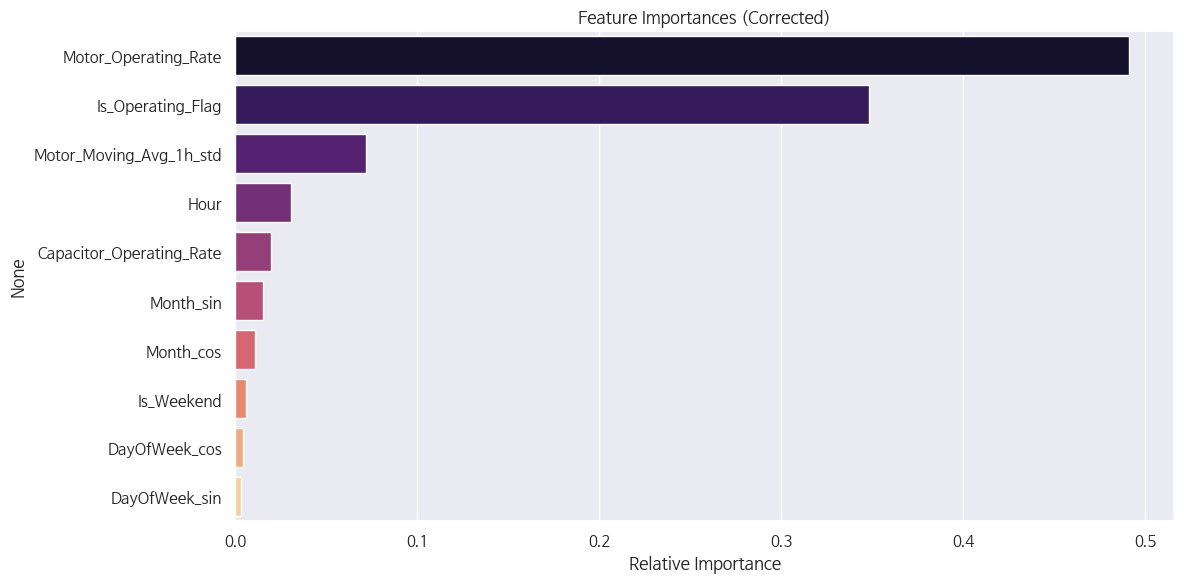

In [17]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model_usage.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Corrected)")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


=== Feature Importance Top 5 ===
Capacitor_Operating_Rate    0.531151
Motor_Moving_Avg_1h_std     0.170825
Hour                        0.080247
Is_Operating_Flag           0.063809
Motor_Operating_Rate        0.059354
dtype: float32


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Feature Importances (Corrected)')

<Axes: title={'center': 'Feature Importances (Corrected)'}, ylabel='None'>

Text(0.5, 0, 'Relative Importance')

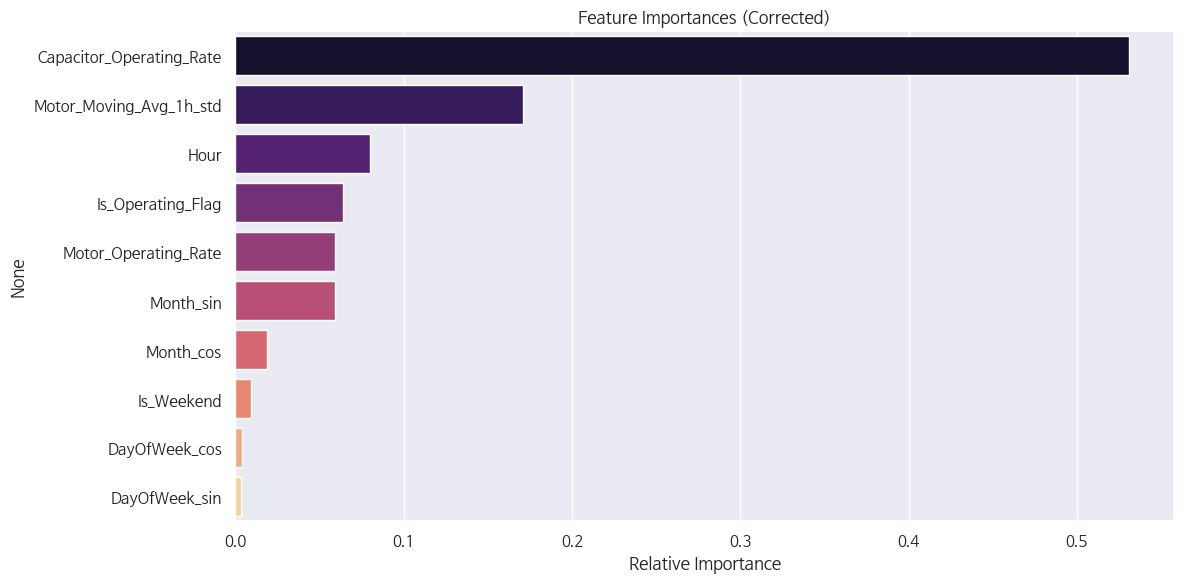

In [18]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model_pf.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Corrected)")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np
import json

def calculate_elec_cost_scenario(
    df: pd.DataFrame,
    config_path: str,
    scenario_name: str,  # 핵심: 여기서 시나리오 이름을 선택
    contract_kw: float = None
) -> pd.DataFrame:

    # 1. 마스터 설정 파일 로드
    with open(config_path, 'r', encoding='utf-8') as f:
        master_config = json.load(f)

    # 2. 특정 시나리오 데이터 추출
    if scenario_name not in master_config['scenarios']:
        raise ValueError(f"시나리오 '{scenario_name}'을(를) 찾을 수 없습니다. 가능한 시나리오: {list(master_config['scenarios'].keys())}")

    config = master_config['scenarios'][scenario_name]
    print(f"▶ 선택된 시나리오: {scenario_name} ({config.get('desc', '')})")

    if contract_kw is None:
        if 'contract_kw' in config:
            contract_kw = config['contract_kw']
            print(f"   └ 계약전력: {contract_kw}kW (시나리오 설정값 적용)")
        else:
            # 안전장치: JSON에도 없고 인자도 없으면 에러
            raise ValueError("contract_kw가 함수 인자로도, JSON 설정으로도 제공되지 않았습니다.")
    else:
        print(f"   └ 계약전력: {contract_kw}kW (사용자 입력값 우선 적용)")

    df = df.copy()

    # --- 이하 로직은 설정값(config)을 사용하여 자동 계산 ---

    # 3. 시간대(TOU) 적용 (config['tou_schedule'] 사용)
    df['tou'] = 'mid' # 기본값

    tou_sched = config['tou_schedule']

    # 제주도 등 특수 케이스 처리를 위한 계절 키 확인
    # (설정에 없는 계절은 무시하거나 에러 처리 가능)
    available_seasons = [s for s in ['summer', 'winter', 'spring_fall'] if s in tou_sched]

    for season in available_seasons:
        season_mask = (df['Season'] == season)
        schedule = tou_sched[season]

        for tou_type, ranges in schedule.items():
            for start, end in ranges:
                # 22시~08시 같은 자정 넘김 처리 (OR 조건)
                if start < end:
                    time_mask = (df['Hour'] >= start) & (df['Hour'] < end)
                else:
                    time_mask = (df['Hour'] >= start) | (df['Hour'] < end)

                df.loc[season_mask & time_mask, 'tou'] = tou_type

    # 4. 토요일/공휴일 특례 (2018/2026 공통 룰 적용)
    # 필요시 이 룰도 config에서 on/off 할 수 있게 확장 가능
    day_of_week = df['date'].dt.dayofweek
    
    # 1) 토요일(5) 특례: 최대부하 -> 중간부하
    sat_mask = (day_of_week == 5) & (df['tou'] == 'peak')
    df.loc[sat_mask, 'tou'] = 'mid'
    
    # 2) 일요일(6) 특례: 24시간 내내 -> 경부하
    sun_mask = (day_of_week == 6)
    df.loc[sun_mask, 'tou'] = 'off'

    # --- 5. 역률 계산 및 가감률 도출 (JSON 기반) ---
    pf_cfg = config.get('pf_logic')

    # JSON에서 시간 설정 가져오기 (없으면 기본값 9, 23 적용)
    lag_start = pf_cfg.get('lag_start', 9) # 기본값 9시
    lag_end = pf_cfg.get('lag_end', 23)    # 기본값 23시

    # 이미지에 명시된 08시~22시 적용
    df['is_lag_period'] = np.where((df['Hour'] >= lag_start) & (df['Hour'] < lag_end), 1, 0)
    
    # 월별/구간별(지상, 진상) 유효/무효 전력 합계
    grouped = df.groupby(['Month', 'is_lag_period']).agg({
        'Usage_kWh': 'sum',
        'Lagging_Current_Reactive_Power_kVarh': 'sum',
        'Leading_Current_Reactive_Power_kVarh': 'sum'
    }).reset_index()
    
    # 1. 무효전력량(kVARh) 컬럼 선택
    # 조건 목록: 지상 구간일 때와 아닐 때(진상)
    pf_conditions = [
        (grouped['is_lag_period'] == 1),  # 지상(Lagging)
        (grouped['is_lag_period'] == 0)   # 진상(Leading)
    ]
    
    # 결과 목록: 각각 사용할 컬럼명
    pf_choices = [
        grouped['Lagging_Current_Reactive_Power_kVarh'],
        grouped['Leading_Current_Reactive_Power_kVarh']
    ]
    
    # np.select로 구간별 kvarh 결정
    kvarh_vec = np.select(pf_conditions, pf_choices, default=0)
    
    # 2. 역률(PF) 값 계산
    with np.errstate(divide='ignore', invalid='ignore'):
        pf_vec = (grouped['Usage_kWh'] / np.sqrt(grouped['Usage_kWh']**2 + kvarh_vec**2)) * 100
        grouped['pf_val'] = np.where(grouped['Usage_kWh'] == 0, 100.0, np.minimum(100.0, pf_vec))
    
    # 3. 역률 가감률(pf_adj) 산정 (이미지 약관 기준 반영)
    rate = pf_cfg['rate_per_1_pct']
    max_adj = pf_cfg['max_adjustment']
    
    
    
    # 조건 목록 정의 (지상/진상 및 기준치 초과/미달)
    adj_conditions = [
        (grouped['is_lag_period'] == 1),  # 지상: 92% 기준 (할인/할증 모두 포함)
        (grouped['is_lag_period'] == 0)   # 진상: 95% 기준 (할증만 적용)
    ]
    
    # 결과 목록 정의
    adj_choices = [
        # 지상: (92 - 현재역률) * 0.002 -> ±10% 클립
        np.clip((pf_cfg['lag_target'] - grouped['pf_val']) * rate, -max_adj, max_adj),
    
        # 진상: 95% 미달 시만 할증 -> 0 ~ 10% 클립
        np.clip((pf_cfg['lead_target'] - grouped['pf_val']) * rate, 0, max_adj)
    ]
    
    grouped['pf_adj'] = np.select(adj_conditions, adj_choices, default=0.0)
    
    # 월별 최종 가감률 매핑
    monthly_adj = grouped.groupby('Month')['pf_adj'].sum().reset_index()
    df = df.merge(monthly_adj.rename(columns={'pf_adj': 'total_pf_adj'}), on='Month', how='left')
    
    # --- 6. 기본요금 산출 및 안분 ---
    # 피크 반영 기본요금 로직 (Billing Demand)
    monthly_peak = df.groupby('Month')['Usage_kWh'].transform('max') * 4
    df['billing_demand'] = np.maximum(monthly_peak, contract_kw * 0.3)
    
    # PF 가감이 반영된 월 총액
    df['monthly_basic_total'] = (df['billing_demand'] * config['base_rate']) * (1 + df['total_pf_adj'])
    
    # 시각화용 15분 안분
    month_total_usage = df.groupby('Month')['Usage_kWh'].transform('sum')
    df['allocated_base'] = np.where(month_total_usage > 0,
                                    df['monthly_basic_total'] * (df['Usage_kWh'] / month_total_usage), 0)
    
    # 5. 요금 계산 (Vectorized)
    price_map = config['unit_prices']
    
    # 단가 매핑 함수
    def get_price(row):
        # 해당 시나리오에 정의된 계절/시간대 단가 가져오기
        try:
            return price_map[row['season']][row['tou']]
        except KeyError:
            return 0.0 # 예외 처리
    
    df['unit_price'] = df.apply(get_price, axis=1)
    df['energy_cost'] = df['Usage_kWh'] * df['unit_price']
    
    
    # --- 7. 부가 요금 및 법정 제비용 (JSON 기반) ---
    fees_cfg = config.get('additional_fees', {})
    
    df['env_cost'] = df['Usage_kWh'] * fees_cfg.get('climate', 0)
    df['fuel_cost'] = df['Usage_kWh'] * fees_cfg.get('fuel', 0)
    
    
    # 공급가액 합계
    df['supply_price'] = df['energy_cost'] + df['env_cost'] + df['fuel_cost'] + df['allocated_base']
    
    # 전력기금 및 부가세 (JSON의 요율 적용)
    fund_rate = fees_cfg.get('fund_rate', 0.032)
    vat_rate = fees_cfg.get('vat_rate', 0.1)
    
    df['fund_cost'] = (df['supply_price'] * fund_rate).apply(np.floor)
    df['vat_cost'] = (df['supply_price'] * vat_rate).apply(lambda x: round(x, 0))
    
    df['total_cost'] = df['supply_price'] + df['fund_cost'] + df['vat_cost']
    
    return df

In [20]:
df['Motor_Operating_Rate'].describe()

count    35040.000000
mean        13.451020
std         16.825921
min          0.000000
25%          2.373336
50%          5.159426
75%         23.361882
max        100.000000
Name: Motor_Operating_Rate, dtype: float64

In [21]:
### Track 1: 완벽히 통합된 베이지안 최적화 목적함수
import pandas as pd
import numpy as np
import optuna
import json

def get_current_unit_price(hour, season, dayofweek, tou_schedule, price_map):
    tou = 'mid'
    schedule = tou_schedule.get(season, {})
    for tou_type, ranges in schedule.items():
        for start, end in ranges:
            if start < end:
                if start <= hour < end: tou = tou_type
            else: 
                if hour >= start or hour < end: tou = tou_type
                
    # 🚨 [핵심] 한전 주말/일요일 특례 완벽 반영
    if dayofweek == 5:   # 토요일
        if tou == 'peak': tou = 'mid'
    elif dayofweek == 6: # 일요일
        tou = 'off'      # 24시간 무조건 경부하
        
    return price_map.get(season, {}).get(tou, 0.0), tou

def load_ai_optimization_config(config_path: str, scenario_name: str) -> tuple:
    """
    JSON 마스터 설정에서 AI 엔진(Track 1)에 필요한 핵심 파라미터만 자동 추출
    """
    with open(config_path, 'r', encoding='utf-8') as f:
        master_config = json.load(f)

    if scenario_name not in master_config['scenarios']:
        raise ValueError(f"시나리오 오류: '{scenario_name}'이(가) JSON에 존재하지 않습니다.")

    scenario = master_config['scenarios'][scenario_name]
    pf_logic = scenario.get('pf_logic', {})

    # 1. AI 엔진(ProcessOptimizer)에 주입할 경량화된 정적 제약 조건
    fast_cost_config = {
        'base_rate': scenario.get('base_rate', 0.0),
        'pf_target': pf_logic.get('lag_target', 90),      # 누락 시 방어적 기본값 90
        'pf_weight': pf_logic.get('rate_per_1_pct', 0.002) # 누락 시 방어적 기본값 0.002
    }

    # 2. 메인 시뮬레이션 루프에서 매 15분마다 단가를 동적으로 찾기 위한 룩업 테이블
    unit_prices = scenario.get('unit_prices', {})
    tou_schedule = scenario.get('tou_schedule', {})

    return fast_cost_config, unit_prices, tou_schedule

class ProcessOptimizer:
    def __init__(self, current_monthly_peak, prev_motor_rate, prev_cap_rate, target_prod_rate, 
                 fast_cost_config, model_usage, model_pf, current_context, features_order, 
                 current_deficit=0.0, max_delta=10.0): # 🚨 [추가] 누적 생산 부족분 파라미터
        """
        Track 1 (Fast Track): 15분 단위 한계 비용 기반 최적화 엔진
        """
        # 1. 동적 상태 변수 (매 15분 스텝마다 외부에서 갱신되어 주입됨)
        self.current_monthly_peak = current_monthly_peak  # 현재까지의 월간 피크 전력
        self.prev_motor_rate = prev_motor_rate            # 직전 스텝 모터 가동률
        self.prev_cap_rate = prev_cap_rate                # 직전 스텝 콘덴서 가동률
        self.target_prod_rate = target_prod_rate          # 방어해야 할 최소 조업 강도 (하한선)
        self.current_context = current_context            # 이번 스텝의 고정 환경 변수 (dict)
        
        # 2. 정적 설정 변수
        self.config = fast_cost_config                    # 탐색용 경량 요금 설정 (단가, 피크단가 등)
        self.model_usage = model_usage                    # Usage_kWh 예측 모델
        self.model_pf = model_pf                          # PF_Physical 예측 모델
        self.features_order = features_order              # 모델 입력 피처 순서 
        
        # 3. 제어 하드 제약 조건
        self.max_delta = max_delta                              # 15분당 설비 조작 최대 변동폭 1년에 맞춰 수정
        self.current_deficit = current_deficit # 🚨 [추가]

        # Optuna의 실험값(motor, cap)과 고정된 환경 변수(context) 병합
        input_dict = {k: self.current_context.get(k, 0) for k in features_order}
        input_dict['Motor_Operating_Rate'] = self.prev_motor_rate   # 수정: 초기 캐싱용 임시값
        input_dict['Capacitor_Operating_Rate'] = self.prev_cap_rate # 수정: 초기 캐싱용 임시값

        base_df = pd.DataFrame([input_dict])

        cat_dtypes = {
        # 0~23의 카테고리 공간을 명시적으로 확정지음
        'Hour': pd.CategoricalDtype(categories=list(range(24)), ordered=False),
        'Is_Weekend': pd.CategoricalDtype(categories=[0, 1], ordered=False),
        'Is_Operating_Flag': pd.CategoricalDtype(categories=[0, 2, 1], ordered=False)
        }
        
        for col, dtype in cat_dtypes.items():
            if col in base_df.columns:
                base_df[col] = base_df[col].astype(dtype)

        # 컬럼 순서 고정 후 인스턴스 변수로 저장
        self.base_df = base_df[features_order]

        # 🚨 [초고속 최적화 1] 컬럼 인덱스 번호를 미리 캐싱해 둡니다.
        self.motor_idx = self.base_df.columns.get_loc('Motor_Operating_Rate')
        self.cap_idx = self.base_df.columns.get_loc('Capacitor_Operating_Rate')
        if 'Is_Operating_Flag' in self.base_df.columns:
            self.flag_idx = self.base_df.columns.get_loc('Is_Operating_Flag')
        else:
            self.flag_idx = None

    def predict_process(self, motor_rate, cap_rate):
        """
        XGBoost 범주형 데이터 타입 에러를 완벽히 방어하기 위한 DataFrame 조립 로직
        """
        
        # .at 인덱서를 사용하여 오버헤드 없이 모터와 콘덴서 값만 교체    
        self.base_df.iat[0, self.motor_idx] = motor_rate
        self.base_df.iat[0, self.cap_idx] = cap_rate

        if self.flag_idx is not None:
            if motor_rate > 5.0:
                self.base_df.iat[0, self.flag_idx] = 2
            else:
                self.base_df.iat[0, self.flag_idx] = 1

        # 물리량 예측 (미리 형변환된 DataFrame을 그대로 사용)
        pred_usage = self.model_usage.predict(self.base_df)[0]
        pred_pf = self.model_pf.predict(self.base_df)[0]

        return pred_usage, pred_pf

    def objective(self, trial):
        original_motor = self.current_context['Motor_Operating_Rate']
        original_usage = self.current_context['Usage_kWh']
        current_tou = self.config['current_tou']
        current_unit_price = self.config['current_unit_price']

        # 1. 물리적 하한선 설정: 주간 감산 초강력 제한 (생산량 사수)
        if current_tou == 'peak':  
            # 🚨 최대부하: 락
            m_low = original_motor 
            m_high = original_motor
        elif current_tou == 'mid':
            # 🚨 중간부하: 락
            m_low = original_motor
            m_high = min(100.0, original_motor + (10.0 if self.current_deficit > 5.0 else 0.0))
        else: # off-peak
            # 경부하(야간): 부채가 있으면 무조건 +30%p 증산 강제
            if self.current_deficit > 5.0:
                m_low = min(100.0, original_motor + 30.0)
                m_high = 100.0
            else:
                m_low = original_motor
                m_high = min(100.0, original_motor + 10.0)
        
        # 안전 장치 및 기계적 한계 적용
        if m_low > m_high: m_low = m_high
        motor_low = max(m_low, self.prev_motor_rate - self.max_delta)
        motor_high = min(m_high, self.prev_motor_rate + self.max_delta)
        if motor_low > motor_high: motor_low = motor_high

        # 커패시터 하한 20% 및 변동폭 적용 [cite: 2026-01-17]
        c_min_limit = 20.0 if original_motor > 5.0 else 0.0
        cap_low = max(c_min_limit, self.prev_cap_rate - self.max_delta)
        cap_high = min(100.0, self.prev_cap_rate + self.max_delta)
        if cap_low > cap_high: cap_low = cap_high

        # 2. Optuna 제안 및 모델 예측
        motor_rate = trial.suggest_float("motor_rate", motor_low, motor_high)
        cap_rate = trial.suggest_float("cap_rate", cap_low, cap_high)
        pred_usage, pred_pf = self.predict_process(motor_rate, cap_rate)

        # 3. 비용 항목별 계산 (NameError 방지) [cite: 2026-02-20]
        # 🚨 여기서 usage_cost를 명확히 정의합니다.
        usage_cost = pred_usage * current_unit_price
        
        # 감산 페널티 (단가의 1000배) [cite: 2026-01-11]
        reduction_penalty = max(0, original_motor - motor_rate) * (current_unit_price * 1000.0)
        
        # 생산 부채 위약금 (야간 증산 유도용) [cite: 2026-01-11]
        step_deficit = original_usage - pred_usage
        expected_total_deficit = self.current_deficit + step_deficit
        deficit_penalty = expected_total_deficit * (current_unit_price * 10.0) if current_tou == 'off' and expected_total_deficit > 0 else 0.0
        # 피크 및 역률 페널티
        peak_penalty = (pred_usage - self.current_monthly_peak) * self.config['base_rate'] if pred_usage > self.current_monthly_peak else 0.0
        pf_target_decimal = self.config.get('pf_target', 0.9)
        if pf_target_decimal > 1.0: 
            pf_target_decimal /= 100.0 
            
        pf_penalty = 0.0
        if pred_pf < pf_target_decimal:
            diff_pct = (pf_target_decimal - pred_pf) * 100.0
            pf_penalty = pred_usage * self.config['pf_weight'] * diff_pct
            
        # 모든 항목 합산하여 반환
        return usage_cost + reduction_penalty + deficit_penalty + peak_penalty + pf_penalty

In [22]:
# import optuna
# import pandas as pd
# import numpy as np
# from tqdm import tqdm

# # ==============================================================================
# # 0. 시뮬레이션 환경 셋업
# # ==============================================================================
# # 검증용 시나리오 고정 (예: 2018년 산업용 고압A 선택3)
# TARGET_SCENARIO = '2018_industrial_HV_A_opt3'
# CONFIG_PATH = 'electricity_config_master.json'

# # Track 1 엔진용 설정 동적 로드
# fast_cost_config, price_map, tou_schedule = load_ai_optimization_config(CONFIG_PATH, TARGET_SCENARIO)

# # 테스트 데이터: 1주일(7일 * 24시간 * 4스텝 = 672스텝) 샘플링
# simulation_df = df.head(672).copy()

# # 🚨 하드코딩 제거: 데이터의 첫 번째 행(Row)을 기준으로 동적 초기화
# first_row = simulation_df.iloc[0]

# # 1) 초기 모터/콘덴서 가동률: 첫 스텝의 실제 기계 상태 동기화
# last_motor_rate = first_row['Motor_Operating_Rate']
# last_cap_rate = first_row['Capacitor_Operating_Rate']

# # 2) 초기 피크 설정: 만약 1일 00시가 아니라면, 최소한 첫 스텝의 실제 사용량 또는 
# # 해당 월의 시뮬레이션 이전까지의 Max값을 찾아와야 함. 
# # (여기서는 가장 안전하게 첫 스텝의 실제 사용량을 기준점으로 부여)
# opt_monthly_peak = first_row['Usage_kWh'] 
# actual_monthly_peak = first_row['Usage_kWh'] 

# opt_results = []

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# print(f"▶ [Track 1] AI 최적화 제어 시뮬레이션 시작 (시나리오: {TARGET_SCENARIO}, 1주일 치)")

# # ==============================================================================
# # 1. Track 1: AI 엔진 가동 및 가상 데이터(Digital Twin) 생성
# # ==============================================================================
# # 🚨 [추가] 일일 생산량 부채(Deficit) 장부
# daily_deficit_kwh = 0.0 
# current_day = simulation_df.iloc[0]['date']

# for index, row in tqdm(simulation_df.iterrows(), total=len(simulation_df), desc="AI 탐색 중"):

#     # 🚨 [수정된 부분] 튜플로 반환된 값을 두 개의 변수(current_price, current_tou)로 받음
#     current_price, current_tou = get_current_unit_price(
#         row['Hour'], row['Season'], row['Is_Weekend'], tou_schedule, price_map
#     )
    
#     # 2. 비가동 시간 개입 허용 (빚이 있으면 공장 문을 강제로 연다)
#     if row['Is_Operating_Flag'] == 0:
#         # 부채가 5kWh 이상 쌓여있고, 현재 전깃값이 싼 'off-peak' 시간대라면?
#         if daily_deficit_kwh > 5.0 and current_tou == 'off':
#             pass # continue 하지 않고 아래 AI 최적화 로직으로 진입시킨다!
#         else:
#             opt_results.append(row.to_dict())
#             continue
        
    
#     # 🚨 [수정된 부분] AI의 뇌(fast_cost_config)에 단가와 현재 부하 상태를 모두 주입
#     fast_cost_config['current_unit_price'] = current_price
#     fast_cost_config['current_tou'] = current_tou
    
#     target_production = row['Motor_Operating_Rate'] * 0.95 # 기존 조업강도 90% 하한선 방어
#     if row['Motor_Operating_Rate'] == 0 and daily_deficit_kwh > 0:
#         target_production = min(100.0, daily_deficit_kwh) # 남은 빚만큼 타겟 설정
    
#     optimizer = ProcessOptimizer(
#         current_monthly_peak=opt_monthly_peak,
#         prev_motor_rate=last_motor_rate,
#         prev_cap_rate=last_cap_rate,
#         target_prod_rate=target_production,
#         fast_cost_config=fast_cost_config,
#         model_usage=model_usage,       
#         model_pf=model_pf,       
#         current_context=row.to_dict(),
#         features_order=features,
#         current_deficit=daily_deficit_kwh
#     )
    
#     study = optuna.create_study(direction="minimize")
#     study.optimize(optimizer.objective, n_trials=30, n_jobs=-1)
    
#     best_motor = study.best_params['motor_rate']
#     best_cap = study.best_params['cap_rate']
    
#     # 예측된 물리량
#     opt_usage, opt_pf = optimizer.predict_process(best_motor, best_cap)

#     # 🚨 [핵심] 실제 조업량 대비 AI가 깎아먹은 전력량(생산량)을 부채 장부에 기입
#     original_expected_usage = row['Usage_kWh'] 
#     daily_deficit_kwh += (original_expected_usage - opt_usage)
    
#     # 상태 업데이트
#     last_motor_rate = best_motor
#     last_cap_rate = best_cap
#     if opt_usage > opt_monthly_peak:
#         opt_monthly_peak = opt_usage
        
#     # 무효전력(kVARh) 역산 (Track 2 호환용)
#     pf_decimal = np.clip(opt_pf / 100.0, 0.01, 1.0)
#     if pf_decimal < 1.0:
#         opt_kvarh_lag = opt_usage * np.sqrt((1 / pf_decimal**2) - 1)
#     else:
#         opt_kvarh_lag = 0.0
        
#     # AI 제어 결과 덮어쓰기
#     new_row = row.copy()
#     new_row['Usage_kWh'] = opt_usage
#     new_row['PF_Physical'] = opt_pf
#     new_row['lagging_current_reactive_power_kvarh'] = opt_kvarh_lag
#     new_row['leading_current_reactive_power_kvarh'] = 0.0 
#     new_row['Motor_Operating_Rate'] = best_motor
#     new_row['Capacitor_Operating_Rate'] = best_cap
    
#     opt_results.append(new_row.to_dict())

# df_ai_controlled = pd.DataFrame(opt_results)
# for col in ['date', 'timestamp']:
#     if col in df_ai_controlled.columns:
#         df_ai_controlled[col] = pd.to_datetime(df_ai_controlled[col])

# # ==============================================================================
# # 2. Track 2: 마스터 함수 기반 최종 요금 정산 및 비교
# # ==============================================================================
# print("\n▶ [Track 2] 마스터 함수 기반 최종 요금 정산 진행 중...")

# # 1) 원본 데이터(인간 제어) 정산
# df_human_bill = calculate_elec_cost_scenario(
#     df=simulation_df, 
#     config_path=CONFIG_PATH, 
#     scenario_name=TARGET_SCENARIO
# )

# # 2) AI 데이터(최적화 제어) 정산
# df_ai_bill = calculate_elec_cost_scenario(
#     df=df_ai_controlled, 
#     config_path=CONFIG_PATH, 
#     scenario_name=TARGET_SCENARIO
# )

# # ==============================================================================
# # 3. ROI 리포트 출력
# # ==============================================================================
# human_total = df_human_bill['total_cost'].sum()
# ai_total = df_ai_bill['total_cost'].sum()
# savings = human_total - ai_total

# print("\n" + "="*50)
# print(f"[{TARGET_SCENARIO}] 1주일(672 스텝) 제어 결과")
# print("="*50)
# print(f"▶ 기존 작업자 제어 요금: {human_total:,.0f} 원")
# print(f"▶ AI 최적화 제어 요금: {ai_total:,.0f} 원")
# print("-" * 50)
# if savings > 0:
#     print(f"✅ AI 제어 절감액: {savings:,.0f} 원 ({(savings/human_total)*100:.2f}% 절감)")
# else:
#     print(f"⚠️ AI 제어 실패 (비용 증가): {savings:,.0f} 원")
# print("="*50)


In [23]:
# human_total_kwh = simulation_df['Usage_kWh'].sum()
# ai_total_kwh = df_ai_controlled['Usage_kWh'].sum()

# print(f"기존 총 전력 사용량: {human_total_kwh:,.0f} kWh")
# print(f"AI 총 전력 사용량: {ai_total_kwh:,.0f} kWh")
# print(f"생산량(전력량) 유지율: {(ai_total_kwh / human_total_kwh) * 100:.2f}%")

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_optimization_profile_usage(df_original, df_ai):
    """
    1주일(또는 1달) 치 시뮬레이션 결과를 시간대별 일간 평균(Mean Daily Profile)으로 압축하여
    Peak Shaving 및 Load Shifting 효과를 전력 사용량(kWh) 기준으로 시각화합니다.
    """
    # 1. 시간대(Hour)별 전력 사용량(Usage_kWh) 평균 산출
    # (모터 가동률과 달리 % 스케일이 아니므로 * 100을 제거합니다)
    mean_orig = df_original.groupby('Hour')['Usage_kWh'].mean()
    mean_opt = df_ai.groupby('Hour')['Usage_kWh'].mean()
    
    hours = mean_orig.index

    # 2. 그래프 스타일 셋업
    plt.figure(figsize=(12, 6))
    sns.set_style("darkgrid")

    # 3. 선 그래프 (Before & After)
    plt.plot(hours, mean_orig, label='Original (Before)', color='grey', linestyle='--', linewidth=1.5)
    plt.plot(hours, mean_opt, label='Optimized (After)', color='blue', linestyle='-', linewidth=2)

    # 4. Peak Shaving (감산 영역: 원본이 더 큰 구간) 빨간색 칠하기
    plt.fill_between(hours, mean_orig, mean_opt, 
                     where=(mean_orig > mean_opt), 
                     interpolate=True, color='lightcoral', alpha=0.6, label='Peak Shaving (Reduced kWh)')

    # 5. Load Shifting (증산 영역: AI가 더 큰 구간) 녹색 칠하기
    plt.fill_between(hours, mean_orig, mean_opt, 
                     where=(mean_opt > mean_orig), 
                     interpolate=True, color='darkseagreen', alpha=0.6, label='Load Shifting (Added kWh)')

    # 6. 축 및 레이블 설정
    plt.title('Optimized Electricity Usage Profile (Mean Daily kWh)', fontsize=16, pad=15)
    plt.xlabel('Hour of Day', fontsize=14)
    plt.ylabel('Electricity Usage (kWh)', fontsize=14)
    
    # 🚨 수정: 하드코딩된 0~110% 스케일 제거. 데이터의 최대 전력량에 맞춰 Y축 동적 세팅
    max_usage = max(mean_orig.max(), mean_opt.max())
    plt.ylim(0, max_usage * 1.15) 
    
    # x축을 2시간 단위로 촘촘하게 배치하여 주간/야간 경계를 더 명확히 파악
    plt.xticks(range(0, 24, 2), fontsize=12)
    plt.yticks(fontsize=12)
    
    plt.legend(fontsize=12, loc='upper right')
    plt.tight_layout()
    plt.show()



In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 33 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 4   CO2_ppm                               35040 non-null  float64       
 5   Lagging_Current_Power_Factor          35040 non-null  float64       
 6   Leading_Current_Power_Factor          35040 non-null  float64       
 7   NSM                                   35040 non-null  int64         
 8   WeekStatus                            35040 non-null  object        
 9   Day_of_week                           35040 non-null  object        
 10

In [26]:
# import optuna
# import pandas as pd
# import numpy as np
# from tqdm import tqdm
# import os

# # 1. 시뮬레이션 메인 셋업
# CONFIG_PATH = 'electricity_config_master.json'
# scenario_candidates = [
#     '2018_industrial_HV_A_opt1',
#     '2018_industrial_HV_A_opt2',
#     '2018_industrial_HV_A_opt3'
# ]

# # 1주일 치 데이터 샘플링
# simulation_df = df.head(672).copy()
# first_row = simulation_df.iloc[0]

# roi_results = {}
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# print("▶ 2018년 기준 요금제별 완벽한 AI 맞춤형 최적화 분석 시작...\n")

# for scenario in scenario_candidates:
#     print("="*60)
#     print(f"🚀 [{scenario}] AI 최적화 및 정산 진행 중...")
    
#     # [1] 시나리오별 설정 로드
#     fast_cost_config, price_map, tou_schedule = load_ai_optimization_config(CONFIG_PATH, scenario)
    
#     # 초기화
#     opt_monthly_peak = first_row['Usage_kWh']
#     last_motor_rate = first_row['Motor_Operating_Rate']
#     last_cap_rate = first_row['Capacitor_Operating_Rate']
#     daily_deficit_kwh = 0.0
#     opt_results = []
    
#     # [2] Track 1: 해당 요금제에 특화된 AI 스케줄 탐색
#     for index, row in tqdm(simulation_df.iterrows(), total=len(simulation_df), desc="AI Scheduling"):
#         # 교정된 dayofweek 로직 적용
#         current_price, current_tou = get_current_unit_price(
#             row['Hour'], row['Season'], row['DayOfWeek'], tou_schedule, price_map
#         )
        
#         if row['Is_Operating_Flag'] == 0:
#             if daily_deficit_kwh > 5.0 and current_tou == 'off':
#                 pass 
#             else:
#                 opt_results.append(row.to_dict())
#                 continue
                
#         fast_cost_config['current_unit_price'] = current_price
#         fast_cost_config['current_tou'] = current_tou
        
#         target_production = row['Motor_Operating_Rate'] * 0.95 
#         if row['Motor_Operating_Rate'] == 0 and daily_deficit_kwh > 0:
#             target_production = min(100.0, daily_deficit_kwh)
            
#         optimizer = ProcessOptimizer(
#             current_monthly_peak=opt_monthly_peak,
#             prev_motor_rate=last_motor_rate,
#             prev_cap_rate=last_cap_rate,
#             target_prod_rate=target_production,
#             fast_cost_config=fast_cost_config,
#             model_usage=model_usage,       
#             model_pf=model_pf,        
#             current_context=row.to_dict(),
#             features_order=features,
#             current_deficit=daily_deficit_kwh
#         )
        
#         study = optuna.create_study(direction="minimize")
#         study.optimize(optimizer.objective, n_trials=30, n_jobs=-1)
        
#         best_motor = study.best_params['motor_rate']
#         best_cap = study.best_params['cap_rate']
#         opt_usage, opt_pf = optimizer.predict_process(best_motor, best_cap)
        
#         daily_deficit_kwh += (row['Usage_kWh'] - opt_usage)
#         last_motor_rate, last_cap_rate = best_motor, best_cap
#         if opt_usage > opt_monthly_peak: opt_monthly_peak = opt_usage
            
#         pf_decimal = np.clip(opt_pf / 100.0, 0.01, 1.0)
#         opt_kvarh_lag = opt_usage * np.sqrt((1 / pf_decimal**2) - 1) if pf_decimal < 1.0 else 0.0
        
#         new_row = row.copy()
#         new_row['Usage_kWh'] = opt_usage
#         new_row['PF_Physical'] = opt_pf
#         new_row['Lagging_Current_Reactive_Power_kVarh'] = opt_kvarh_lag
#         new_row['Leading_Current_Reactive_Power_kVarh'] = 0.0 
#         new_row['Motor_Operating_Rate'] = best_motor
#         new_row['Capacitor_Operating_Rate'] = best_cap
        
#         opt_results.append(new_row.to_dict())
        
#     df_ai_controlled_scenario = pd.DataFrame(opt_results)
#     if 'date' in df_ai_controlled_scenario.columns:
#         df_ai_controlled_scenario['date'] = pd.to_datetime(df_ai_controlled_scenario['date'])

#     # [3] Track 2: 정산 및 투 트랙(Two-Track) 지표 평가
#     # 1. 재무 지표 (Financial Metrics) 산출
#     df_human_bill = calculate_elec_cost_scenario(simulation_df, CONFIG_PATH, scenario)
#     human_total_cost = df_human_bill['total_cost'].sum()
    
#     df_ai_bill = calculate_elec_cost_scenario(df_ai_controlled_scenario, CONFIG_PATH, scenario)
#     ai_total_cost = df_ai_bill['total_cost'].sum()
    
#     savings_krw = human_total_cost - ai_total_cost
#     savings_rate = (savings_krw / human_total_cost) * 100

#     # 2. 운영/조업 지표 (Operational Metrics) 산출
#     # 2-1. 생산량 유지율 (Total kWh 보존 여부)
#     human_total_kwh = df_human_bill['Usage_kWh'].sum()
#     ai_total_kwh = df_ai_bill['Usage_kWh'].sum()
#     production_retention = (ai_total_kwh / human_total_kwh) * 100

#     # 2-2. 월간 최대수요전력(Peak kW) 억제 효과 (기본요금 하락의 핵심)
#     # 15분 단위 사용량(kWh)에 4를 곱해 1시간 평균 전력(kW)으로 환산하여 최대치 비교
#     human_peak_kw = df_human_bill['Usage_kWh'].max() * 4
#     ai_peak_kw = df_ai_bill['Usage_kWh'].max() * 4
#     peak_reduction_kw = human_peak_kw - ai_peak_kw

#     # 3. 결과 딕셔너리 저장
#     roi_results[scenario] = {
#         'human_cost': human_total_cost,
#         'ai_cost': ai_total_cost,
#         'savings_krw': savings_krw,
#         'savings_rate': savings_rate,
#         'production_retention': production_retention,
#         'peak_reduction_kw': peak_reduction_kw
#     }
    
#     # 4. 콘솔 출력 (면접관/클라이언트 보고용 포맷)
#     print(f" ├─ [재무 성과] As-Is: {human_total_cost:,.0f}원 ➔ To-Be: {ai_total_cost:,.0f}원")
#     print(f" │             ✅ 절감액: {savings_krw:,.0f}원 ({savings_rate:.2f}% ↓)")
#     print(f" └─ [조업 방어] 생산량 유지율: {production_retention:.2f}% (100% 근접 시 정상)")
#     print(f"               ⚡ 피크 전력 변동: {human_peak_kw:.1f}kW ➔ {ai_peak_kw:.1f}kW (▼{peak_reduction_kw:.1f}kW)")

#     plot_optimization_profile_usage(simulation_df, df_ai_controlled_scenario)

In [27]:
import os
import gc
import traceback
import pandas as pd
import numpy as np
import optuna
from tqdm import tqdm
from joblib import Parallel, delayed

# 🚨 경고: joblib 병렬 처리 시 모델 충돌을 막기 위해 전역 스레드 제한 필수
model_usage.set_params(n_jobs=1)
model_pf.set_params(n_jobs=1)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. 독립적인 월별 최적화 작업자 함수 (Worker Function)
def optimize_chunk(chunk_df, month_idx, config_path, scenario_name, features_order):
    
    # [폭탄 제거 1] 워커 내부에서 Optuna 로그 폭주 강제 차단 (Jupyter 커널 폭파 방지)
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    fast_cost_config, price_map, tou_schedule = load_ai_optimization_config(config_path, scenario_name)
    
    opt_results = []
    daily_deficit_kwh = 0.0
    
    # 🚨 각 월의 첫 데이터로 초기화
    current_day = chunk_df.iloc[0]['date']
    opt_monthly_peak = chunk_df.iloc[0]['Usage_kWh']
    last_motor_rate = chunk_df.iloc[0]['Motor_Operating_Rate']
    last_cap_rate = chunk_df.iloc[0]['Capacitor_Operating_Rate']
    
    for index, row in chunk_df.iterrows():
        if row['date'] != current_day:
            daily_deficit_kwh = 0.0
            current_day = row['date']

        if row['Is_Operating_Flag'] == 0:
            opt_results.append(row.to_dict())
            continue

        current_price, current_tou = get_current_unit_price(row['Hour'], row['Season'], row['Is_Weekend'], tou_schedule, price_map)
        fast_cost_config['current_unit_price'] = current_price
        fast_cost_config['current_tou'] = current_tou
        
        optimizer = ProcessOptimizer(
            current_monthly_peak=opt_monthly_peak,
            prev_motor_rate=last_motor_rate,
            prev_cap_rate=last_cap_rate,
            target_prod_rate=row['Motor_Operating_Rate'] * 0.95,
            fast_cost_config=fast_cost_config,
            model_usage=model_usage,
            model_pf=model_pf,
            current_context=row.to_dict(),
            features_order=features_order,
            current_deficit=daily_deficit_kwh,
            max_delta=fast_cost_config.get('max_delta', 10.0)
        )
        
        # 워커 내부에서는 직렬 탐색 (충돌 방지)
        study = optuna.create_study(direction="minimize")
        study.optimize(optimizer.objective, n_trials=30, n_jobs=1) 
        
        best_motor = study.best_params['motor_rate']
        best_cap = study.best_params['cap_rate']
        opt_usage, opt_pf = optimizer.predict_process(best_motor, best_cap)
        
        daily_deficit_kwh += (row['Usage_kWh'] - opt_usage)
        last_motor_rate, last_cap_rate = best_motor, best_cap
        if opt_usage > opt_monthly_peak: opt_monthly_peak = opt_usage
            
        pf_decimal = np.clip(opt_pf, 0.01, 1.0)
        
        new_row = row.copy()
        new_row['Usage_kWh'] = opt_usage
        new_row['PF_Physical'] = opt_pf
        new_row['Lagging_Current_Reactive_Power_kVarh'] = opt_usage * np.sqrt((1 / pf_decimal**2) - 1)
        new_row['Leading_Current_Reactive_Power_kVarh'] = 0.0
        new_row['Motor_Operating_Rate'] = best_motor
        new_row['Capacitor_Operating_Rate'] = best_cap
        
        opt_results.append(new_row.to_dict())
        
    # [폭탄 제거 2] 인덱스 소실 방지: 원본 청크의 인덱스를 씌워서 반환 (시계열 붕괴 방지)
    return pd.DataFrame(opt_results, index=chunk_df.index)



,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


In [28]:
# 🚨 [수정됨] 버전 호환성을 타지 않는 범용 tqdm 어댑터
import contextlib
import joblib
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# 3. 12분할 병렬 처리 실행부
if __name__ == "__main__":
    TARGET_SCENARIO = '2018_industrial_HV_A_opt3'
    CONFIG_PATH = 'electricity_config_master.json'

    print("==================================================")
    print(f"🚀 [12개월 분할 멀티프로세싱] 가동 시작")
    print("==================================================")

    try:
        simulation_df = df.copy()
        
        # 🚨 [수정] 이미 존재하는 Month 칼럼을 직접 참조하여 분할
        month_col = 'Month' if 'Month' in simulation_df.columns else 'month'
        
        # Month 칼럼을 기준으로 데이터 쪼개기
        chunks = [group for _, group in simulation_df.groupby(month_col)]
        print(f"데이터를 {len(chunks)}개의 월별 청크로 분할 완료. 각 코어에 할당합니다...")

        # 🚨 [폭탄 제거 3] 한글 윈도우 계정명(권영민)으로 인한 ASCII 인코딩 에러 원천 차단
        # C드라이브 최상단에 영어로만 된 임시 폴더를 강제로 생성하여 joblib에 할당
        import os
        safe_temp_dir = 'C:/joblib_temp_dir'
        os.makedirs(safe_temp_dir, exist_ok=True)

        # 🚨 [수정됨] 어댑터를 씌우고 tqdm 프로그레스 바 가동
        with tqdm_joblib(tqdm(desc="[12개월 최적화 진행률]", total=len(chunks))) as progress_bar:
            parallel_results = Parallel(n_jobs=12, temp_folder=safe_temp_dir)(
                delayed(optimize_chunk)(chunk_df, idx, CONFIG_PATH, TARGET_SCENARIO, features) 
                for idx, chunk_df in enumerate(chunks)
            )

        # 4. 병렬 처리된 12달치 결과를 다시 1년치 파일로 결합
        df_ai_controlled = pd.concat(parallel_results).sort_index()
        
        for col in ['date', 'timestamp']:
            if col in df_ai_controlled.columns:
                df_ai_controlled[col] = pd.to_datetime(df_ai_controlled[col])
                
        final_filename = f'final_1_year_MULTIPROCESS_{TARGET_SCENARIO}.csv'
        df_ai_controlled.to_csv(final_filename, index=False)
        print(f"✅ 멀티프로세싱 병렬 최적화 완료. 파일 저장됨: {final_filename}")

    except Exception as e:
        print(f"\n❌ 실행 중 오류 발생:")
        traceback.print_exc()

🚀 [12개월 분할 멀티프로세싱] 가동 시작
데이터를 12개의 월별 청크로 분할 완료. 각 코어에 할당합니다...


[12개월 최적화 진행률]:   0%|          | 0/12 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 정렬 및 기본 연산
human_df = simulation_df.copy()
ai_df = df_ai_controlled.copy()

# 2. 핵심 KPI 지표 계산
# 2-1. 조업 방어율 (Total Usage)
human_total_usage = human_df['Usage_kWh'].sum()
ai_total_usage = ai_df['Usage_kWh'].sum()
production_retention = (ai_total_usage / human_total_usage) * 100

# 2-2. 최대 수요 전력 (Peak kW, 15분 단위이므로 * 4)
human_peak_kw = human_df['Usage_kWh'].max() * 4
ai_peak_kw = ai_df['Usage_kWh'].max() * 4
peak_reduction_kw = human_peak_kw - ai_peak_kw

# 2-3. 역률 개선 (Average Power Factor)
# 가동 중일 때(Is_Operating_Flag > 0)의 역률만 평균 계산
human_avg_pf = human_df[human_df['Is_Operating_Flag'] > 0]['PF_Physical'].mean()
ai_avg_pf = ai_df[ai_df['Is_Operating_Flag'] > 0]['PF_Physical'].mean()

print("==================================================")
print("[Track 1] 1년 치 (35,040 스텝) 물리적 제어 성과 검증")
print("==================================================")
print(f"▶ 조업 방어율 (생산량 유지): {production_retention:.2f}%")
if 99.0 <= production_retention <= 101.0:
    print("   └ [정상] Zero-Tolerance 제약 조건이 완벽히 작동했습니다.")
else:
    print("   └ [경고] 생산량 방어 실패. 타겟 누수나 하한선 로직을 재점검해야 합니다.")
print("--------------------------------------------------")
print(f"▶ 최대 수요 전력 (Peak): {human_peak_kw:.1f} kW ➔ {ai_peak_kw:.1f} kW")
print(f"   └ [효과] {peak_reduction_kw:.1f} kW 피크 감소 (기본요금 인하 요인)")
print("--------------------------------------------------")
print(f"▶ 평균 역률 (가동 시): {(human_avg_pf * 100):.1f}% ➔ {(ai_avg_pf * 100):.1f}%")
print(f"   └ [효과] 역률 {((ai_avg_pf - human_avg_pf) * 100):.1f}%p 개선 (Track 2 지상/진상 요금 할인 요인)")
print("==================================================")

# 3. Load Shifting 시간대별 프로필 시각화
hourly_human = human_df.groupby('Hour')['Usage_kWh'].mean()
hourly_ai = ai_df.groupby('Hour')['Usage_kWh'].mean()

plt.figure(figsize=(14, 6))
plt.plot(hourly_human.index, hourly_human.values, label='As-Is (Human)', linestyle='--', color='gray', linewidth=2)
plt.plot(hourly_ai.index, hourly_ai.values, label='To-Be (AI)', color='blue', linewidth=2)

# Peak Shaving (주간 감산)과 Load Shifting (야간 증산) 영역 색상 표시
plt.fill_between(hourly_human.index, hourly_human.values, hourly_ai.values, 
                 where=(hourly_human.values > hourly_ai.values), color='red', alpha=0.3, label='Peak Shaving (Red)')
plt.fill_between(hourly_human.index, hourly_human.values, hourly_ai.values, 
                 where=(hourly_human.values < hourly_ai.values), color='green', alpha=0.3, label='Load Shifting (Green)')

plt.title('1-Year Average Hourly Electricity Usage Profile (Load Shifting Validation)', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Average Usage (kWh)', fontsize=12)
plt.xticks(range(24))
plt.legend(fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# 원본 데이터프레임의 역률 스케일 확인
display(df['PF_Physical'].describe())

# 혹시 결측치나 이상치가 있는지 상위 5개 값 확인
display(df['PF_Physical'].head())